# PushTで学ぶRoboOps入門

## はじめに：RoboOpsで重要となる3つの観点

ロボット学習では、実機やシミュレータを使ってデータを収集し、Policyを学習させ、実際にロボットを動かして評価します。

この一連の処理はパソコンの中だけでは完結しません。結果はコードだけでなく、データセット、学習設定、ロボットやセンサー、周囲の環境など、さまざまな条件に左右されます。さらに、データ収集・学習・評価には時間がかかり、試す条件の組み合わせも膨大になります。

そのため、使用した条件や成果物を管理し、データや振る舞いを検証し、その処理を繰り返し実行できるように自動化する**RoboOps**の考えが重要になります。RoboOpsでは、これらを管理・検証・自動化の3つの観点で扱います。

| 観点 | 目的 | この教材で行うこと |
|---|---|---|
| **管理** | どのコード・データ・モデル・設定・実行環境で動いたのかを残し、**再現性を確保できるようにする** | Docker、Git / GitHub、DatasetのID / revision、学習設定 / checkpoint |
| **検証** | 変更後のデータ・コード・Policyが壊れていないか、必要な品質や性能を満たすかを客観的に確認し、**信頼性を確保できるようにする** | Dataset検査、ruff / pytest、学習時のloss、シミュレータ評価 |
| **自動化** | ビルド・学習・評価などを人の手作業に頼らず繰り返せるようにし、**継続的かつ規模を拡大して運用できるようにする** | GitHub Actions、Dockerの自動ビルド、学習経路の確認、シミュレータ上での自動評価 |

この3つを組み合わせることで、ロボット学習の仕組み全体を、再現性と信頼性を確保しながら継続的に改善・運用できるようになります。このNotebookではPushTを題材に、**管理・検証・自動化**からなるRoboOpsの流れに取り組みます。


## 0. 実行環境を固定する【管理】

Dockerは、OSやライブラリなど、実行に必要なものをまとめ、異なるPCでも同じ環境を動かしやすくする仕組みです。DockerfileからDockerイメージを作り、そのイメージをもとにコンテナを起動します。

この教材の実行環境もDockerfileから構築されています。必要なPythonパッケージは `pyproject.toml` で定義し、実際に使用するバージョンは `uv.lock` に記録しています。Dockerのビルド時に、パッケージ管理ツールのuvが `uv.lock` に従ってインストールすることで、同じパッケージ構成を再現できるようにしています。

さらに、乱数seedやCPUの実行条件を固定することで、学習や評価の条件を揃えています。以下では、実行環境と実行条件を確認します。


In [1]:
from pathlib import Path
import importlib.metadata
import json
import logging
import os
import platform
import time
import warnings

from IPython import get_ipython
from IPython.display import Markdown, Video, display

get_ipython().run_line_magic('matplotlib', 'inline')
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch

# どこから起動しても、Repository直下を作業場所にします。
PROJECT_ROOT = next(
    path for path in [Path.cwd(), Path.cwd().parent, Path('/workspace')]
    if (path / 'pyproject.toml').exists()
)
os.chdir(PROJECT_ROOT)
# 学習条件を比較できるよう、乱数とCPU thread数を固定します。
SEED = 42
TORCH_THREADS = 4
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.set_num_threads(TORCH_THREADS)

print('Project:', PROJECT_ROOT)


Project: /workspace


In [2]:
print('OS:', platform.platform())
print('Python:', platform.python_version())
print('PyTorch:', torch.__version__)
print('LeRobot:', importlib.metadata.version('lerobot'))
print('gym-pusht:', importlib.metadata.version('gym-pusht'))
print('Device: CPU')


OS: Linux-6.10.14-linuxkit-aarch64-with-glibc2.36
Python: 3.12.14
PyTorch: 2.11.0+cpu
LeRobot: 0.6.1
gym-pusht: 0.1.6
Device: CPU


## 1. PushTのtaskを確認する【管理】

この教材では、PushTと呼ばれるtaskを題材にRoboOpsに取り組みます。はじめに、PushTがどのようなtaskで、どのような入出力を持つかを確認します。

PushTは、平面上の青いagentを動かし、灰色のT字ブロックを緑の目標領域へ押し込むtaskです。[1] 観測、action、rewardは次のとおりです。

- **Observation**: `[agent_x, agent_y, block_x, block_y, block_angle]`。agentとT字ブロックの位置、ブロックの回転角（radian）
- **Action**: agentが次に向かう目標座標 `(x, y)`
- **Reward**: T字ブロックと目標領域の重なり。重なりが95%を超えるとsuccess


### PushTの初期状態を確認する

ランダムな初期状態を可視化してみましょう。青いagent、灰色のT字ブロック、緑のgoalの位置関係と、初期状態のobservation・rewardを確認します。

> **Tips:** Simulatorのversion、初期化seed、最大step数、成功条件を記録すると、同じ条件で結果を比較できます。


Observation [agent_x, agent_y, block_x, block_y, block_angle]: [ 85.    359.    330.924 304.378   2.253]
Reward: 0.060


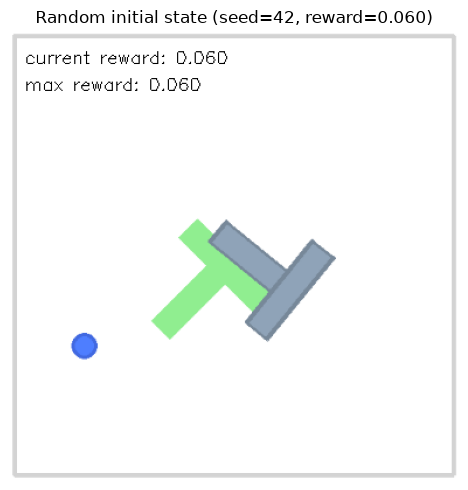

In [3]:
warnings.filterwarnings('ignore', message='pkg_resources is deprecated.*')
import gym_pusht  # PushT環境をGymnasiumへ登録
import gymnasium as gym

def show_reward(frame, current, maximum):
    image = np.asarray(frame).copy()
    cv2.rectangle(image, (6, 6), (205, 58), (255, 255, 255), -1)
    cv2.putText(image, f'current reward: {current:.3f}', (12, 27), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 0, 1)
    cv2.putText(image, f'max reward: {maximum:.3f}', (12, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 0, 1)
    return image

preview_env = gym.make(
    'gym_pusht/PushT-v0', obs_type='state', render_mode='rgb_array',
    max_episode_steps=300, visualization_width=384, visualization_height=384,
)
# 同じ初期状態を再現できるよう、seedを固定します。
initial_observation, _ = preview_env.reset(seed=42)
# 状態を進めず、初期配置のgoal coverageからrewardを計算します。
coverage = preview_env.unwrapped._get_coverage()
initial_reward = float(np.clip(coverage / preview_env.unwrapped.success_threshold, 0.0, 1.0))
initial_frame = show_reward(preview_env.render(), initial_reward, initial_reward)
print('Observation [agent_x, agent_y, block_x, block_y, block_angle]:', np.round(initial_observation, 3))
print(f'Reward: {initial_reward:.3f}')
preview_env.close()

plt.figure(figsize=(5, 5))
plt.imshow(initial_frame)
plt.title(f'Random initial state (seed=42, reward={initial_reward:.3f})')
plt.axis('off')
plt.tight_layout()
plt.show()


### Random policyでSimulatorの動きを確認する

動画でPushT taskを可視化してみましょう。Randomなactionでagentを動かし、各時点の `current reward` と、それまでの `max reward` を表示します。

> **Tips:** seedとstep数を記録しておくと、同じ初期状態と動きを再実行できます。


In [4]:
import imageio.v3 as iio

random_env = gym.make(
    'gym_pusht/PushT-v0', obs_type='state', render_mode='rgb_array',
    max_episode_steps=120, visualization_width=384, visualization_height=384,
)
random_observation, _ = random_env.reset(seed=48)
rng = np.random.default_rng(48)
random_delta = np.zeros(2)
random_coverage = random_env.unwrapped._get_coverage()
random_initial_reward = float(np.clip(
    random_coverage / random_env.unwrapped.success_threshold, 0.0, 1.0,
))
random_frames = [show_reward(random_env.render(), random_initial_reward, random_initial_reward)]
random_max_reward, random_success = random_initial_reward, False
# 前stepの変化量を残し、random actionを連続的にします。
for _ in range(120):
    random_delta = np.clip(0.9 * random_delta + rng.normal(0, 8, size=2), -40, 40)
    random_action = np.clip(random_observation[:2] + random_delta, 0, 512)
    random_observation, reward, terminated, truncated, info = random_env.step(random_action)
    random_max_reward = max(random_max_reward, float(reward))
    random_success = random_success or info['is_success']
    random_frames.append(show_reward(random_env.render(), float(reward), random_max_reward))
    if terminated or truncated:
        break
random_env.close()

RANDOM_VIDEO_PATH = Path('artifacts/evaluation/rollout-random.mp4')
RANDOM_VIDEO_PATH.parent.mkdir(parents=True, exist_ok=True)
iio.imwrite(RANDOM_VIDEO_PATH, np.stack(random_frames), fps=10, codec='libx264')
print(f'Random policy: max reward={random_max_reward:.3f}, success={random_success}')
display(Video(str(RANDOM_VIDEO_PATH), embed=True, width=480))


Random policy: max reward=0.662, success=False


通常の模倣学習では、`Simulator / 実機を用いてデータを収集 → データを前処理 → 学習` と進みます。

今回は120分でRoboOps全体を一周するため、データ収集を省略し、収集済みのPushT DatasetをHugging Faceから取得します。Datasetを受け取り、管理・検証するところから始めます。


## 2. DatasetのIDとversionを記録する【管理】

これから取得する `lerobot/pusht_keypoints` は、先ほど見たPushTの操作軌跡をepisode単位で記録したDatasetです。[2]

Hugging Face Dataset Hubは、Datasetを保存・共有し、IDとrevisionを指定して取得できるサービスです。revisionはDatasetのversionを特定する値で、branch名、tag名、commit hashを指定できます。ここでは更新に左右されず同じDatasetを取得できるよう、commit hashをコード上に記録します。

> **Tips:** Gitはコードの差分管理に向いていますが、大容量のDatasetやモデルweightを直接保存すると、更新のたびに履歴が膨らみ、cloneや取得が重くなります。そのため、コードとconfigはGit / GitHub、DatasetやPolicyはversionを付けて配布・取得しやすいHugging Face、実行環境はDockerで管理します。


In [5]:
warnings.filterwarnings('ignore', message='IProgress not found.*')
from huggingface_hub import hf_hub_download
from lerobot.datasets import LeRobotDataset

# Datasetが更新されても同じ内容を取得できるよう、revisionを固定します。
DATASET_ID = 'lerobot/pusht_keypoints'
REVISION = 'ace8c161a68bc025c21a5f29f85b86a9a2c5e64b'
RAW_ROOT = Path('data/raw/lerobot_pusht_keypoints') / REVISION
FILES = [
    'meta/info.json', 'meta/stats.json', 'meta/tasks.parquet',
    'meta/episodes/chunk-000/file-000.parquet',
    'data/chunk-000/file-000.parquet',
]
for filename in FILES:
    if not (RAW_ROOT / filename).exists():
        hf_hub_download(
            DATASET_ID, filename, repo_type='dataset',
            revision=REVISION, local_dir=RAW_ROOT,
        )
logging.getLogger('lerobot.utils.import_utils').setLevel(logging.ERROR)
dataset = LeRobotDataset(
    DATASET_ID, root=RAW_ROOT, revision=REVISION, download_videos=False,
)
print(f'Loaded: {DATASET_ID}@{REVISION[:12]} ({dataset.num_episodes} episodes)')


Loaded: lerobot/pusht_keypoints@ace8c161a68b (206 episodes)


### LeRobot Datasetの形式を確認する

LeRobot Datasetは、ロボット学習データを共通の形式で保存・読み込む仕組みです。ロボットごとにカメラ画像、関節角度、keypointsなどの中身は異なりますが、episodeの構造やmetadataの持ち方が揃っているため、`LeRobotDataset` を使って同じ方法で読み込めます。

Datasetにどのfieldがあり、それぞれがどのようなdtype、shape、fpsを持つかというデータ構造の定義を **schema** と呼びます。LeRobot Datasetでは、このschemaがmetadataに記録されています。

まず、metadataに記録されたfieldをすべて表示します。


In [6]:
print('Dataset fields:')
for name in dataset.meta.features:
    print('-', name)


Dataset fields:
- observation.state
- observation.environment_state
- action
- episode_index
- frame_index
- timestamp
- next.reward
- next.done
- next.success
- index
- task_index


### 学習に使うfieldを確認する

PushTでは、1 recordが0.1秒ごとの1時点です。学習に使う主なfieldは次の3つです。

| Field | 入っている値 | 意味 |
|---|---|---|
| `observation.state` | `[agent_x, agent_y]` | 現在のagent位置 |
| `observation.environment_state` | `[x0, y0, ..., x7, y7]` | 現在のT字ブロックを表す8 keypoints |
| `action` | `[target_x, target_y]` | agentが次に向かう位置 |

8 keypointsは、Simulator内部のT字ブロックの位置と回転角から、輪郭上の8点をxy座標へ変換した値です。agent・ブロック・actionを同じxy座標系で扱え、角度の周期性も避けられます。

次のセルでは、この3つのfieldのdtype、shape、fpsをmetadataから表示します。

> **Tips:** schemaをversionと一緒に記録すると、Dataset更新によるfieldやshapeの変化を検出できます。


In [7]:
MAIN_FIELDS = ['observation.state', 'observation.environment_state', 'action']
schema_rows = [
    f"| `{name}` | `{dataset.meta.features[name]['dtype']}` | `{dataset.meta.features[name]['shape']}` | {dataset.meta.features[name]['fps']} |"
    for name in MAIN_FIELDS
]
display(Markdown(
    '| field | dtype | shape | fps |\n|---|---|---|---:|\n' + '\n'.join(schema_rows)
))


| field | dtype | shape | fps |
|---|---|---|---:|
| `observation.state` | `float32` | `(2,)` | 10 |
| `observation.environment_state` | `float32` | `(16,)` | 10 |
| `action` | `float32` | `(2,)` | 10 |

Datasetから必要なfieldを取り出してNumPy配列へ変換し、episode数、shape、先頭recordの値を確認します。


In [8]:
samples = [dataset[index] for index in range(len(dataset))]
agent = torch.stack([row['observation.state'] for row in samples]).numpy()
environment = torch.stack([row['observation.environment_state'] for row in samples]).numpy()
actions = torch.stack([row['action'] for row in samples]).numpy()
episode_index = torch.stack([row['episode_index'] for row in samples]).numpy()
frame_index = torch.stack([row['frame_index'] for row in samples]).numpy()
episodes, lengths = np.unique(episode_index, return_counts=True)

print(f'Episodes: {len(episodes)} / Frames: {len(actions):,}')
print(f'Episode length: min={lengths.min()}, mean={lengths.mean():.1f}, max={lengths.max()}')
print('agent:', agent.shape, 'environment:', environment.shape, 'action:', actions.shape)
print(f"\nEpisode {int(episode_index[0])}, frame {int(frame_index[0])}, time {float(samples[0]['timestamp']):.1f}s")
print('Current agent (x, y):', agent[0].round(1).tolist())
print('T keypoints (x, y):\n', environment[0].reshape(8, 2).round(1))
print('Action target (x, y):', actions[0].round(1).tolist())


Episodes: 206 / Frames: 25,650
Episode length: min=49, mean=124.5, max=246
agent: (25650, 2) environment: (25650, 16) action: (25650, 2)

Episode 0, frame 0, time 0.0s
Current agent (x, y): [222.0, 97.0]
T keypoints (x, y):
 [[282.5 373.6]
 [163.5 389.6]
 [159.5 359.9]
 [278.5 343.9]
 [233.9 349.9]
 [204.1 353.9]
 [192.1 264.7]
 [221.9 260.7]]
Action target (x, y): [233.0, 71.0]


### Datasetの1 episodeをリプレイする

Datasetに記録されたデータをPushT Simulatorで動かし、可視化してみましょう。数値だけでは分かりにくい、青いagent、灰色のT字ブロック、緑のgoal、赤い十字のactionの動きを再生し、時系列として自然に動いているかを確認します。

> **Tips:** schemaと統計が正常でも、座標軸の反転や時系列のずれは見逃すことがあります。機械的なvalidationにリプレイによる目視確認を組み合わせます。


In [9]:
replay_episode = episodes[min(20, len(episodes) - 1)]
mask = episode_index == replay_episode
# 8 keypointsからT字ブロックの初期位置と角度を復元します。
keypoints = environment[mask][0].reshape(8, 2)
angle = np.arctan2(*(keypoints[1] - keypoints[0])[::-1])
rotation = np.array([[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]])
block_position = keypoints[0] - rotation @ np.array([-60, 0])

replay_env = gym.make(
    'gym_pusht/PushT-v0', obs_type='state', render_mode='rgb_array',
    max_episode_steps=int(mask.sum()), visualization_width=384, visualization_height=384,
)
replay_env.reset(seed=0)
simulator = replay_env.unwrapped
simulator.agent.position = agent[mask][0].tolist()
simulator.block.angle = float(angle)
simulator.block.position = block_position.tolist()
simulator.space.step(simulator.dt)

replay_frames, replay_max_reward, replay_success = [replay_env.render()], 0.0, False
# Datasetに記録されたactionを順番にSimulatorへ入力します。
for action in actions[mask]:
    _, reward, terminated, truncated, info = replay_env.step(action)
    replay_frames.append(replay_env.render())
    replay_max_reward = max(replay_max_reward, float(reward))
    replay_success = replay_success or info['is_success']
    if terminated or truncated:
        break
replay_env.close()

REPLAY_VIDEO_PATH = Path('artifacts/evaluation/replay-dataset.mp4')
REPLAY_VIDEO_PATH.parent.mkdir(parents=True, exist_ok=True)
iio.imwrite(REPLAY_VIDEO_PATH, np.stack(replay_frames), fps=10, codec='libx264')
print(f'Episode {replay_episode}: max reward={replay_max_reward:.3f}, success={replay_success}')
display(Video(str(REPLAY_VIDEO_PATH), embed=True, width=480))


Episode 20: max reward=1.000, success=True


## 3. Datasetのschemaと品質を確かめる【検証】

ロボットから収集するDatasetは、多数のepisodeを含むため、すべてを目視で確認するのは困難です。そこで、**全recordを自動で検査し、人は代表sampleと検出された異常を確認する**ように役割を分けます。

validatorを作成し、正しいデータとわざと壊したデータを用いて、挙動を確認しましょう。


In [10]:
REQUIRED = ['observation.state', 'observation.environment_state', 'action', 'episode_index']
EXPECTED_SHAPES = {
    'observation.state': (2,),
    'observation.environment_state': (16,),
    'action': (2,),
}

def validate(data):
    # 必須fieldがすべて存在するか
    if any(key not in data for key in REQUIRED):
        return 'FAIL'

    # 各fieldのrecord数が同じで、空ではないか
    counts = [len(data[key]) for key in REQUIRED]
    if counts[0] == 0 or len(set(counts)) != 1:
        return 'FAIL'

    # 各fieldのshapeが定義どおりか
    shapes_ok = all(
        np.asarray(data[key]).ndim == 2
        and np.asarray(data[key]).shape[1:] == shape
        for key, shape in EXPECTED_SHAPES.items()
    ) and np.asarray(data['episode_index']).ndim == 1
    if not shapes_ok:
        return 'FAIL'

    numeric = [data[key].astype(float) for key in REQUIRED[:3]]

    # 数値にNaNやinfが含まれていないか
    if not all(np.isfinite(array).all() for array in numeric):
        return 'FAIL'

    # 座標値が想定範囲を大きく外れていないか
    if not all(np.abs(array).max() <= 1024 for array in numeric):
        return 'FAIL'

    # 各episodeに5 record以上あるか
    episode_lengths = np.unique(data['episode_index'], return_counts=True)[1]
    if episode_lengths.min() < 5:
        return 'FAIL'

    return 'PASS'


### validatorの挙動を確認する

まず、正常なsample dataを通します。


In [11]:
data = {
    'observation.state': np.full((5, 2), 128.0),
    'observation.environment_state': np.full((5, 16), 256.0),
    'action': np.full((5, 2), 130.0),
    'episode_index': np.zeros(5, dtype=int),
}
validate(data)


'PASS'

次に、わざと壊したdataを通します。


In [12]:
broken = {
    'observation.state': np.full((4, 2), np.nan),
    'observation.environment_state': np.full((4, 16), 2048.0),
    'action': np.full((4, 2), 130.0),
    'episode_index': np.zeros(4, dtype=int),
}
validate(broken)


'FAIL'

正常なdataはPASSし、broken dataはFAILしました。最後に、取得したLeRobot Datasetを通します。


In [13]:
downloaded = dict(zip(REQUIRED, [agent, environment, actions, episode_index], strict=True))
validate(downloaded)


'PASS'

取得したDatasetもPASSしたため、学習へ進みます。


## 4. Datasetを学習用に前処理する【検証】

LeRobot DatasetをACTの学習に使える形へ前処理します。actionの時系列から学習に使う16 stepの短いchunkを作り、Datasetをtrain / validationに分割して、各fieldを正規化します。

### train / validationの分け方

train / validationはseed 42でepisodeを並べ替え、約80% / 20%へepisode単位で分割します。chunk単位でDatasetを分割してしまうと、隣接するchunkが同じ未来actionを大きく共有し、ほぼ同じstate / actionがtrainとvalidationの両方に入るdata leakageが起きるためです。

### lossとclosed-loop評価

train / validation lossは、Datasetに記録されたstateに対して、記録されたactionにどれだけ近い予測ができたかを示します。lossが下がっていても、Simulatorや実機でtaskを成功できるとは限りません。

実際の動作では、Policyが出したactionによって次のstateが変わり、そのstateから次のactionを予測します。小さな誤差が積み重なったときに修正できるかは、Dataset上のlossだけでは分かりません。そのため、PolicyをSimulatorや実機で繰り返し動かし、最終的にtaskを達成できたかを測る **closed-loop評価** が重要です。

このNotebookでは、lossは学習が進んでいるかを確認する参考値として扱い、task性能は後半のSimulator rolloutで評価します。学習条件を決めた後、全episodeを使ってPolicyを再学習する運用もありますが、その場合もclosed-loop評価は別に行います。


In [14]:
from torch.utils.data import DataLoader, TensorDataset

CHUNK_SIZE = 16
chunked_dataset = LeRobotDataset(
    DATASET_ID, root=RAW_ROOT, revision=REVISION, download_videos=False,
    delta_timestamps={'action': [step / dataset.fps for step in range(CHUNK_SIZE)]},
)
chunked_samples = [chunked_dataset[index] for index in range(len(chunked_dataset))]
chunks = torch.stack([row['action'] for row in chunked_samples]).numpy()
is_pad = torch.stack([row['action_is_pad'] for row in chunked_samples]).numpy()

# 隣接chunkのdata leakageを防ぐため、episode単位で分割します。
validation_episodes = np.random.default_rng(SEED).permutation(episodes)[:round(len(episodes) * 0.2)]
validation_mask = np.isin(episode_index, validation_episodes)
train_indices = np.flatnonzero(~validation_mask)
validation_indices = np.flatnonzero(validation_mask)

raw = {
    'observation.state': agent,
    'observation.environment_state': environment,
    'action': actions,
}
# validation側の情報を混ぜず、train側だけから正規化統計を計算します。
stats = {
    key: {'mean': value[train_indices].mean(0), 'std': np.maximum(value[train_indices].std(0), 1e-6)}
    for key, value in raw.items()
}

def normalized(key, value):
    return (value - stats[key]['mean']) / stats[key]['std']

BATCH_SIZE = 128

def make_loader(indices, shuffle):
    dataset = TensorDataset(
        torch.tensor(normalized('observation.state', agent[indices])).float(),
        torch.tensor(normalized('observation.environment_state', environment[indices])).float(),
        torch.tensor(normalized('action', chunks[indices])).float(),
        torch.tensor(is_pad[indices]),
    )
    return DataLoader(
        dataset, batch_size=BATCH_SIZE, shuffle=shuffle,
        generator=torch.Generator().manual_seed(SEED),
    )

train_loader = make_loader(train_indices, True)
validation_loader = make_loader(validation_indices, False)
assert chunks.shape == (len(agent), CHUNK_SIZE, 2)
assert is_pad.shape == chunks.shape[:2]
assert not np.intersect1d(episode_index[train_indices], validation_episodes).size
assert all(np.isfinite(normalized(key, value)).all() for key, value in raw.items())
print(f'PASS: preprocessing schema / Train {len(train_indices):,} / Validation {len(validation_indices):,}')


PASS: preprocessing schema / Train 20,500 / Validation 5,150


## 5. 学習条件と成果物を記録する【管理】

同じコードとDatasetを使っても、configやseedが違えば学習結果は変わります。そこでDataset revision、seed、Policy config、epoch数、実行時間、loss、checkpointをひとまとまりで記録します。

この教材では、LeRobotに実装されているACTを使用します。[3]

下のセルでは、CPUで実行できるようにmodel parameterを小さくしたACTを定義します。


In [15]:
from lerobot.configs.types import FeatureType, PolicyFeature
from lerobot.policies.act.configuration_act import ACTConfig
from lerobot.policies.act.modeling_act import ACTPolicy

# CPUで短時間に学習できるサイズへ固定したPolicy configです。
config = ACTConfig(
    input_features={
        'observation.state': PolicyFeature(FeatureType.STATE, (2,)),
        'observation.environment_state': PolicyFeature(FeatureType.ENV, (16,)),
    },
    output_features={'action': PolicyFeature(FeatureType.ACTION, (2,))},
    chunk_size=CHUNK_SIZE,
    n_action_steps=1,
    pre_norm=True,
    dim_model=64,
    n_heads=4,
    dim_feedforward=256,
    n_encoder_layers=2,
    n_decoder_layers=1,
    use_vae=False,
    temporal_ensemble_coeff=0.01,
    dropout=0.1,
    device='cpu',
)
policy = ACTPolicy(config)
TRAINING_COMPLETE = False
print(f'Parameters: {sum(parameter.numel() for parameter in policy.parameters()):,}')


Parameters: 171,714


### 学習を実行し、条件と結果を記録する

30 epochの学習を行います。train lossは毎epoch、validation lossは5 epochごとに記録し、学習条件と結果を対応付けます。


In [16]:
def act_batch(values):
    state, env, action, padding = values
    return {
        'observation.state': state,
        'observation.environment_state': env,
        'action': action,
        'action_is_pad': padding,
    }

EPOCHS = 30
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
optimizer = torch.optim.AdamW(
    policy.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
)
TRAINING_COMPLETE = False
history = []
started = time.perf_counter()
# train lossは毎epoch、validation lossは5 epochごとと最終epochに記録します。
for epoch in range(1, EPOCHS + 1):
    policy.train()
    train_losses = []
    for values in train_loader:
        loss, _ = policy(act_batch(values))
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(policy.parameters(), 1.0)
        optimizer.step()
        train_losses.append(loss.detach().item())
    row = {'epoch': epoch, 'train': np.mean(train_losses)}
    message = f"{epoch:02d}/{EPOCHS}: train loss={row['train']:.3f}"
    if epoch % 5 == 0 or epoch == EPOCHS:
        policy.eval()
        with torch.inference_mode():
            validation_losses = [policy(act_batch(values))[0].item() for values in validation_loader]
        row['validation'] = np.mean(validation_losses)
        message += f", validation loss={row['validation']:.3f}"
    history.append(row)
    print(message)
training_seconds = time.perf_counter() - started
TRAINING_COMPLETE = True
print(f'Training: {training_seconds:.1f}秒')


01/30: train loss=0.394
02/30: train loss=0.324
03/30: train loss=0.303
04/30: train loss=0.290
05/30: train loss=0.280, validation loss=0.282
06/30: train loss=0.274
07/30: train loss=0.266
08/30: train loss=0.261
09/30: train loss=0.257
10/30: train loss=0.253, validation loss=0.278
11/30: train loss=0.250
12/30: train loss=0.247
13/30: train loss=0.244
14/30: train loss=0.241
15/30: train loss=0.239, validation loss=0.272
16/30: train loss=0.238
17/30: train loss=0.234
18/30: train loss=0.234
19/30: train loss=0.231
20/30: train loss=0.229, validation loss=0.259
21/30: train loss=0.228
22/30: train loss=0.226
23/30: train loss=0.224
24/30: train loss=0.223
25/30: train loss=0.222, validation loss=0.264
26/30: train loss=0.221
27/30: train loss=0.218
28/30: train loss=0.218
29/30: train loss=0.217
30/30: train loss=0.216, validation loss=0.261
Training: 163.9秒


### 学習成果物を一式で保存する

checkpointには学習済みweightとACT configを保存し、同じdirectoryへ正規化統計、Dataset revision、学習条件と履歴も保存します。

> **Tips:** model weightとconfigをcheckpointへ一緒に保存すると、どの条件で作られたモデルかを後から確認できます。


Checkpoint: artifacts/checkpoints/lerobot-act (682.9 KiB)


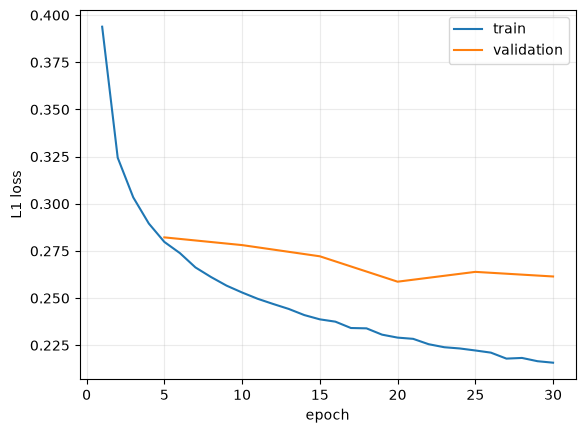

In [17]:
# weight、config、正規化統計、学習履歴を同じdirectoryへ保存します。
training_finished = (
    globals().get('TRAINING_COMPLETE', False)
    and len(history) == EPOCHS
    and history[-1]['epoch'] == EPOCHS
)
if not training_finished:
    raise RuntimeError(f'{EPOCHS} epochの学習が完了していないため、checkpointを保存できません。')

CHECKPOINT_DIR = Path('artifacts/checkpoints/lerobot-act')
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
policy.save_pretrained(CHECKPOINT_DIR)
np.savez(CHECKPOINT_DIR / 'normalization.npz', **{
    f'{key}.{stat}': value for key, values in stats.items() for stat, value in values.items()
})
run_metadata = {
    'dataset': {
        'id': DATASET_ID, 'revision': REVISION,
        'episodes': len(episodes), 'frames': len(actions),
    },
    'training': {
        'seed': SEED, 'epochs': EPOCHS, 'batch_size': BATCH_SIZE,
        'optimizer': 'AdamW', 'learning_rate': LEARNING_RATE,
        'weight_decay': WEIGHT_DECAY, 'torch_threads': TORCH_THREADS,
    },
    'split': {
        'method': 'episode', 'validation_ratio': 0.2, 'seed': SEED,
        'validation_episodes': validation_episodes.tolist(),
    },
    'environment': {
        'platform': platform.platform(),
        'python': platform.python_version(), 'pytorch': torch.__version__,
        'lerobot': importlib.metadata.version('lerobot'),
        'gym_pusht': importlib.metadata.version('gym-pusht'), 'device': 'cpu',
    },
    'policy_config': 'config.json',
    'seconds': training_seconds, 'history': history,
}
(CHECKPOINT_DIR / 'training_metrics.json').write_text(
    json.dumps(run_metadata, indent=2) + '\n'
)
size = sum(path.stat().st_size for path in CHECKPOINT_DIR.glob('*'))
print(f'Checkpoint: {CHECKPOINT_DIR} ({size / 1024:.1f} KiB)')

plt.plot([row['epoch'] for row in history], [row['train'] for row in history], label='train')
validation_history = [row for row in history if 'validation' in row]
plt.plot(
    [row['epoch'] for row in validation_history],
    [row['validation'] for row in validation_history], label='validation',
)
plt.xlabel('epoch'); plt.ylabel('L1 loss'); plt.grid(alpha=0.25); plt.legend()
plt.show()


## 6. Policyの振る舞いをSimulatorで確かめる【検証】

lossだけではPushTの成功を判断できません。固定した20 seedでSimulatorを動かし、各episodeの最大rewardとsuccess、全体のsuccess rateを記録します。最初に成功したepisodeを動画へ保存し、成功がなければ最大rewardのepisodeを保存します。

> **補足:** ACTは各stepで未来16 actionを予測します。現在実行する1 actionは、過去のstepから重なって予測されたactionをtemporal ensembleでまとめて決めます。


### 評価に使用するcheckpointを読み込む

自分で学習したcheckpointが保存されていればそれを使い、なければ[Hugging Face](https://huggingface.co/cnatsu/roboops-pusht-act)から30 epoch学習済みのcheckpointを取得します。


In [18]:
from huggingface_hub import snapshot_download

MODEL_ID = 'cnatsu/roboops-pusht-act'
MODEL_REVISION = 'ca394daa541d6ac39081f00ce64501de71401c9d'
LOCAL_CHECKPOINT_DIR = Path('artifacts/checkpoints/lerobot-act')
REQUIRED_FILES = ['model.safetensors', 'config.json', 'normalization.npz', 'training_metrics.json']

if all((LOCAL_CHECKPOINT_DIR / name).exists() for name in REQUIRED_FILES):
    CHECKPOINT_DIR = LOCAL_CHECKPOINT_DIR
else:
    CHECKPOINT_DIR = Path('artifacts/checkpoints/lerobot-act-pretrained')
    snapshot_download(
        repo_id=MODEL_ID, revision=MODEL_REVISION,
        local_dir=CHECKPOINT_DIR, allow_patterns=REQUIRED_FILES,
    )

policy = ACTPolicy.from_pretrained(CHECKPOINT_DIR)
with np.load(CHECKPOINT_DIR / 'normalization.npz') as normalization:
    stats = {
        key: {stat: normalization[f'{key}.{stat}'] for stat in ('mean', 'std')}
        for key in MAIN_FIELDS
    }

print(f'Loaded checkpoint: {CHECKPOINT_DIR}')


Loading weights from local directory
Loaded checkpoint: artifacts/checkpoints/lerobot-act


### checkpointをテストする

保存したcheckpointで1回だけ推論し、checkpointの読込から推論までのパイプラインが壊れていないかを確認します。このような確認をテストと呼びます。


In [ ]:
# Datasetの先頭recordをPolicyの入力へ変換します。
example = {
    'observation.state': torch.tensor(normalized('observation.state', agent[0])).float().unsqueeze(0),
    'observation.environment_state': torch.tensor(normalized('observation.environment_state', environment[0])).float().unsqueeze(0),
}
policy.eval()
with torch.inference_mode():
    predicted_chunk = policy.predict_action_chunk(example)

assert policy.config.dim_model == 64
assert predicted_chunk.shape == (1, CHUNK_SIZE, 2)
assert torch.isfinite(predicted_chunk).all()
print('PASS: checkpointの読込、Dataset入力、action出力')


### SimulatorでPolicyを評価する

読み込んだPolicyを20個の固定seedで動かし、各episodeの最大rewardとsuccessを記録します。各stepでは、観測を正規化してPolicyへ入力し、予測されたactionを元の座標へ戻してSimulatorへ渡します。成功したepisodeがあれば最初の1本を、成功がなければ最大rewardのepisodeを動画として保存します。


In [19]:
EVAL_EPISODES = 20
EVAL_SEED = 1000
MAX_STEPS = 300
VIDEO_PATH = Path('artifacts/evaluation/rollout-lerobot-act.mp4')
results = []
successful_frames = successful_episode = None
best_frames = best_episode = None
best_video_reward = -1.0
env = gym.make(
    'gym_pusht/PushT-v0', obs_type='environment_state_agent_pos',
    render_mode='rgb_array', max_episode_steps=MAX_STEPS,
    visualization_width=384, visualization_height=384,
)
policy.eval()
started = time.perf_counter()
# 評価条件を揃えるため、1000から始まる固定seedを使います。
for episode in range(EVAL_EPISODES):
    observation, _ = env.reset(seed=EVAL_SEED + episode)
    policy.reset()
    initial_coverage = env.unwrapped._get_coverage()
    initial_reward = float(np.clip(initial_coverage / env.unwrapped.success_threshold, 0.0, 1.0))
    maximum_reward, success = initial_reward, False
    episode_frames = (
        [show_reward(env.render(), initial_reward, initial_reward)]
        if successful_frames is None else None
    )
    for _ in range(MAX_STEPS):
        batch = {
            'observation.state': torch.tensor(normalized('observation.state', observation['agent_pos'])).float().unsqueeze(0),
            'observation.environment_state': torch.tensor(normalized('observation.environment_state', observation['environment_state'])).float().unsqueeze(0),
        }
        action = policy.select_action(batch)[0].numpy()
        # Policy出力を元の座標scaleへ戻してからSimulatorへ入力します。
        action = np.clip(action * stats['action']['std'] + stats['action']['mean'], 0, 512)
        observation, reward, terminated, truncated, info = env.step(action)
        maximum_reward = max(maximum_reward, float(reward))
        success = success or bool(info.get('is_success', False))
        if episode_frames is not None:
            episode_frames.append(show_reward(env.render(), float(reward), maximum_reward))
        if terminated or truncated:
            break
    results.append({'seed': EVAL_SEED + episode, 'max_reward': maximum_reward, 'success': success})
    if success and successful_frames is None:
        successful_frames, successful_episode = episode_frames, episode
        best_frames = None
    elif successful_frames is None and maximum_reward > best_video_reward:
        best_frames, best_episode = episode_frames, episode
        best_video_reward = maximum_reward
    if success or (episode + 1) % 5 == 0:
        print(f'{episode + 1:02d}/{EVAL_EPISODES}: reward={maximum_reward:.3f}, success={success}')
env.close()
evaluation_seconds = time.perf_counter() - started
frames = successful_frames if successful_frames is not None else best_frames
video_episode = successful_episode if successful_episode is not None else best_episode
video_kind = 'successful' if successful_frames is not None else 'best reward'
VIDEO_PATH.parent.mkdir(parents=True, exist_ok=True)
iio.imwrite(VIDEO_PATH, np.stack(frames), fps=10, codec='libx264')
print(f"Video: {video_kind} episode / seed={EVAL_SEED + video_episode}")


05/20: reward=1.000, success=True
10/20: reward=0.868, success=False
15/20: reward=0.220, success=False
20/20: reward=0.093, success=False
Video: successful episode / seed=1004


In [20]:
mean_reward = float(np.mean([row['max_reward'] for row in results]))
success_rate = float(np.mean([row['success'] for row in results]))
# 集計値とepisodeごとの結果を同じJSONへ保存します。
metrics = {
    'checkpoint': str(CHECKPOINT_DIR),
    'dataset': {'id': DATASET_ID, 'revision': REVISION},
    'evaluation': {
        'episodes': EVAL_EPISODES, 'seed': EVAL_SEED, 'max_steps': MAX_STEPS,
    },
    'mean_max_reward': mean_reward, 'success_rate': success_rate,
    'seconds': evaluation_seconds, 'episode_results': results,
}
METRICS_PATH = Path('artifacts/evaluation/metrics-lerobot-act.json')
METRICS_PATH.write_text(json.dumps(metrics, indent=2) + '\n')
assert METRICS_PATH.exists()
print(f'Mean max reward: {mean_reward:.3f}')
print(f'Success rate: {success_rate:.0%}')
print(f'Evaluation: {evaluation_seconds:.1f}秒')
display(Video(str(VIDEO_PATH), embed=True, width=480))


Mean max reward: 0.457
Success rate: 5%
Evaluation: 31.7秒


## 7. GitHub Actionsで検証を自動化する【自動化】

Gitは、コードや設定ファイルの変更履歴をリポジトリとして記録する仕組みです。GitHubは、そのリポジトリをオンラインで保存・共有・管理するサービスです。変更をひとまとまりの履歴として記録する操作をcommit、ローカルのcommitをGitHubへ送る操作をpushと呼びます。

ここまで行ってきた管理・検証の流れを、GitHubへpushするたびにGitHub Actionsで自動実行します。

コードの変更をリポジトリへ取り込むたびに、ビルドやテストを自動で実行し、問題を早く見つける仕組みを **CI（Continuous Integration：継続的インテグレーション）** と呼びます。

今回のGitHub Actionsでは、次の処理を実行します。

- Docker imageをビルドする
- RuffとpytestでコードやNotebookを検査する
- PushT Datasetを20 episode取得し、データを検証する
- 小型ACT（`dim_model=32`、20 update）で学習からcheckpoint保存までを実行する
- 保存したPolicyをSimulator上で3 episode評価する

RuffはPythonコードの問題を静的に検査し、pytestは用意したテストを実行して期待どおり動くかを確認するツールです。

CIでは短時間で完了するように、Dataset、モデル、学習、評価を小さくしています。ここで確認するのはPolicyの性能ではなく、コードを変更した後も一連の処理が最後まで動くことです。

### CIの設定を確認する

GitHub Actionsは、リポジトリの `.github/workflows/` に置いたYAMLファイルで設定します。次は `.github/workflows/ci.yml` の主要部分です。

```yaml
on: [push, pull_request]
steps:
  - run: docker compose build
  - run: docker compose run --rm workshop ruff check .
  - run: docker compose run --rm workshop python src/download_dataset.py --max-episodes 20
  - run: docker compose run --rm workshop pytest -q
  - run: docker compose run --rm workshop python src/validate_dataset.py
  - run: docker compose run --rm workshop python src/train.py --config configs/train_ci.yaml
  - run: docker compose run --rm workshop python src/eval.py --config configs/eval_ci.yaml
```
`on`には実行するタイミング、`steps`には実行する処理を上から順番に記述します。この設定では、GitHubへのpushまたはpull requestをきっかけにCIが動きます。

### GitHubへ教材を登録する

GitHub Actionsを動かすため、ダウンロードした教材をGitリポジトリとして初期化し、自分のprivateリポジトリをGitHub上に作成して教材一式をpushします。ホスト側のターミナルで次を実行し、`YOUR_NAME` と `YOUR_EMAIL` は自分の情報へ置き換えてください。

```bash
git init -b main
git config user.name "YOUR_NAME"
git config user.email "YOUR_EMAIL"
git add .
git commit -m "Complete RoboOps workshop"
gh repo create roboops-workshop --private --source=. --remote=origin --push
```

前半のコマンドで教材をGitの管理対象として最初のcommitを作り、最後のコマンドでGitHub上にprivateリポジトリを作成してpushします。

push後、作成したリポジトリのActions tabを開き、各処理と最終的なPASS / FAILを確認します。


# まとめ

このNotebookでは、PushTを題材に、ロボット学習における管理・検証・自動化を一通り実行しました。

- **管理:** Dockerで実行環境を固定し、DatasetのIDとrevision、学習条件、weight・config・正規化統計を含むcheckpointを記録しました。これにより、どの条件で実行した結果なのかを後から確認し、再現できます。
- **検証:** Datasetのschemaと値を検査し、リプレイによる目視確認も行いました。学習後はlossだけで判断せず、固定した20 seedでSimulator評価を行い、Policyの振る舞いとsuccess rateを確認しました。
- **自動化:** Dockerのビルド、コードとDatasetの検査、小規模な学習・評価をGitHub Actionsで実行しました。コードを変更してpushした後も、同じ検証を繰り返せます。

RoboOpsでは、学習だけを単独で扱うのではなく、実行環境、Dataset、学習条件、checkpoint、Simulator評価を一つの流れとして扱います。管理によって条件を再現できるようにし、検証によって結果を確認し、その検証を自動化することで、ロボット学習の仕組みを継続的に改善・運用できるようになります。


# チャレンジ課題

## チャレンジ1：講義で説明しなかったコードを読む

本編ではNotebookの操作に集中し、実行環境やCIで使うコードの詳細は扱いませんでした。次のfileを開き、Notebookで行った処理と対応付けてみましょう。

- `Dockerfile` / `compose.yaml`：実行環境、volume、port、環境変数
- `.github/workflows/ci.yml`：実行条件と、自動実行する処理の順序
- `src/download_dataset.py` / `validate_dataset.py` / `train.py` / `eval.py`：CIから呼び出す処理
- `configs/train_ci.yaml` / `eval_ci.yaml`：通常実行から短縮しているparameter

すべての行を理解する必要はありません。各fileが管理・検証・自動化のどこで使われているかを確認してください。

## チャレンジ2：学習を発展させる

### 2-A：自分でDatasetを収集する

PushTを手動操作してDatasetを収集し、自分で収集したデータを管理・検証してみましょう。

### 2-B：学習量を増やす

epoch数やDatasetの量を増やし、同じ評価条件で学習結果がどう変わるか比較してみましょう。

### 2-C：Policyをversion付きで配布する

保存したPolicyと評価結果をHugging Face Model Hubへ置き、versionを付けて管理・配布してみましょう。

### 2-D：画像Policyへ広げる

GPU環境と画像付きDatasetを用意し、カメラ画像を入力するACTやDiffusion Policyへ広げてみましょう。

## チャレンジ3：実際のDatasetのvalidationを考える

実際のロボットDatasetには、画像、state、action、sensor、timestampなど、さまざまなデータが含まれます。このような複雑なDatasetに対して、どのようなvalidationが必要でしょうか。

まず、収集時に混入する可能性があるbad dataを考えてみましょう。そのうえで、次の観点からvalidationを設計してください。

- どのようなbad dataが想定されるか
- どの項目を自動checkできるか
- どの項目は人によるsample確認が必要か
- どのような状態をFAILとするか
- 過去のDatasetからの変化をどのように検出するか

> **Tips:** shapeやdtypeが正常でも、画像の内容、sensorのずれ、収集環境の変化などは残る可能性があります。schemaだけでは検出できない問題も含めて考えてください。


# 参考文献

[1] Hugging Face: [gym-pusht](https://github.com/huggingface/gym-pusht), GitHub, 2024, アクセス日：2026年9月3日

[2] LeRobot: [pusht_keypoints](https://huggingface.co/datasets/lerobot/pusht_keypoints), Hugging Face Dataset Hub, 2024, アクセス日：2026年9月3日

[3] Tony Z. Zhao, Vikash Kumar, Sergey Levine, Chelsea Finn: [Learning Fine-Grained Bimanual Manipulation with Low-Cost Hardware](https://arxiv.org/abs/2304.13705), arXiv:2304.13705, 2023, アクセス日：2026年9月3日
